# From probabilities to events: T2K, NOvA and DUNE with real fluxes

In `oscillation_plots.ipynb` we looked at probabilities $P(\nu_\alpha\to\nu_\beta)$.
An experiment, however, counts **events**. Here we fold the oscillation probability with

* the **unoscillated flux** at the far detector, from the public releases of T2K, NOvA and DUNE
  (files in `fluxes/`, see `fluxes/README.md`);
* a simple **CC cross section**, $\sigma_\nu \simeq 0.70\times10^{-38}\,\mathrm{cm^2}\,E/\mathrm{GeV}$,
  $\sigma_{\bar\nu} \simeq 0.35\times10^{-38}\,\mathrm{cm^2}\,E/\mathrm{GeV}$ per nucleon;
* the detector **mass** and the **exposure** (protons on target, POT):

$$
\frac{dN_{\alpha\to\beta}}{dE} = \Phi_\alpha(E)\; P(\nu_\alpha\to\nu_\beta; E)\; \sigma_\beta(E)\;
N_\mathrm{nucleons}\;\mathrm{POT}.
$$

Everything is still a simplification: no detection efficiency, no neutral-current background,
a toy energy resolution. The numbers are nevertheless close to the real ones, within a factor
$\sim 1.5$–$2$ once efficiencies are taken into account.

**Units:** $E$ in GeV, $L$ in km, $\Phi$ in $\nu/\mathrm{cm^2/GeV/POT}$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from nuosc import (NeutrinoOscillator, EXPERIMENTS, ACCELERATORS, get_experiment,
                   load_flux, expected_events, group_rates, integrate, histogram, smear,
                   cross_section_cc, FLAVOUR_LATEX, K_PHASE)

from nuosc.plotting import set_style
SET_STYLE = True     # True: nuosc style (latex_style -> SciencePlots -> default); False: keep your own matplotlib settings
c = set_style(SET_STYLE)   # list of colours used in the plots

FLAV_COLOR = {"numu": c[0], "numubar": c[1], "nue": c[2], "nuebar": c[3]}

def flav(f):
    return rf"${FLAVOUR_LATEX[f]}$"

## 0. Configuration

Experiment setups (baseline, density, flux files, detector mass, POT, toy energy resolution)
are in `nuosc/experiments.py`. Change the values below and re-run.

In [ ]:
# ------------------------------------------------------------------ #
EXPERIMENT = "DUNE"            # "T2K", "NOvA", "DUNE"
MODE       = "FHC"             # "FHC" (neutrino beam) or "RHC" (antineutrino beam)
COMPARE    = ACCELERATORS      # ["T2K", "NOvA", "DUNE"]
MATTER     = True              # include matter effects in the event rates
N_ENERGY   = 3000              # points of the fine true-energy grid
# ------------------------------------------------------------------ #

exp = get_experiment(EXPERIMENT)
E = np.linspace(*exp["E_range"], N_ENERGY)        # fine true-energy grid [GeV]
osc = {o: NeutrinoOscillator.from_experiment(EXPERIMENT, ordering=o) for o in ("NO", "IO")}

print(f"{'':6s} {'L [km]':>7s} {'mass [kt]':>10s} {'POT FHC':>9s} {'POT RHC':>9s} {'dE/E':>5s}")
for name in ACCELERATORS:
    cfg = get_experiment(name)
    print(f"{name:6s} {cfg['baseline']:7.0f} {cfg['mass_kt']:10.1f} "
          f"{cfg['pot']['FHC']:9.2e} {cfg['pot']['RHC']:9.2e} {cfg['resolution']:5.2f}")

        L [km]  mass [kt]   POT FHC   POT RHC  dE/E
T2K        295       22.5  2.00e+21  1.60e+21  0.10
NOvA       810       14.0  2.66e+21  1.25e+21  0.09
DUNE      1300       40.0  3.85e+21  3.85e+21  0.15


## 1. The unoscillated fluxes

### 1a. All flavours for the selected experiment

The beam is mostly $\nu_\mu$ (FHC) or $\bar\nu_\mu$ (RHC). The *wrong-sign* component and the
*intrinsic* $\nu_e/\bar\nu_e$ contamination (from muon and kaon decays) are backgrounds for the
appearance search.

Flux(DUNE, FHC)  [nu / cm^2 / GeV / POT]
  nue     :  501 bins, 0.00-125.2 GeV, integral = 1.543e-16 /cm^2/POT
  numu    :  501 bins, 0.00-125.2 GeV, integral = 1.548e-14 /cm^2/POT
  nuebar  :  501 bins, 0.00-125.2 GeV, integral = 3.827e-17 /cm^2/POT
  numubar :  501 bins, 0.00-125.2 GeV, integral = 1.255e-15 /cm^2/POT 

Flux(DUNE, RHC)  [nu / cm^2 / GeV / POT]
  nue     :  501 bins, 0.00-125.2 GeV, integral = 4.816e-17 /cm^2/POT
  numu    :  501 bins, 0.00-125.2 GeV, integral = 1.533e-15 /cm^2/POT
  nuebar  :  501 bins, 0.00-125.2 GeV, integral = 1.236e-16 /cm^2/POT
  numubar :  501 bins, 0.00-125.2 GeV, integral = 1.385e-14 /cm^2/POT


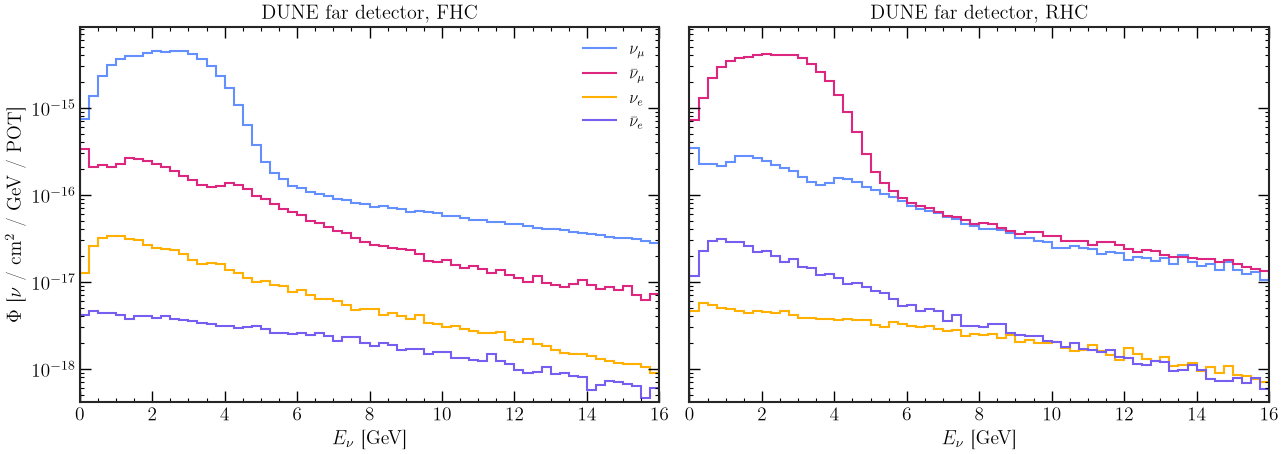

In [ ]:
flux = {m: load_flux(EXPERIMENT, m) for m in ("FHC", "RHC")}
print(flux["FHC"], "\n")
print(flux["RHC"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, m in zip(axes, ("FHC", "RHC")):
    for f in ("numu", "numubar", "nue", "nuebar"):
        ax.stairs(flux[m].values[f], flux[m].edges[f], color=FLAV_COLOR[f], label=flav(f), lw=1.5)
    ax.set_yscale("log")
    ax.set_ylim(1e-4 * flux[m].values["numu" if m == "FHC" else "numubar"].max(), None)
    ax.set_xlim(0, 2 * exp["E_range"][1])
    ax.set_xlabel(r"$E_\nu$ [GeV]")
    ax.set_title(f"{EXPERIMENT} far detector, {m}")
axes[0].set_ylabel(r"$\Phi$ [$\nu$ / cm$^2$ / GeV / POT]")
axes[0].legend()
plt.tight_layout()
plt.show()

### 1b. Comparing the $\nu_\mu$ beams

Fluxes normalised to unit area. The dotted lines mark the first oscillation maximum,
$\Delta_{31} = \pi/2 \Rightarrow E = 2\cdot 1.267\,\Delta m^2_{31} L/\pi$.
T2K (2.5° off-axis) and NOvA (0.8° off-axis) have narrow-band beams centred on the maximum;
DUNE is on-axis and wide-band, covering the first and part of the second maximum.

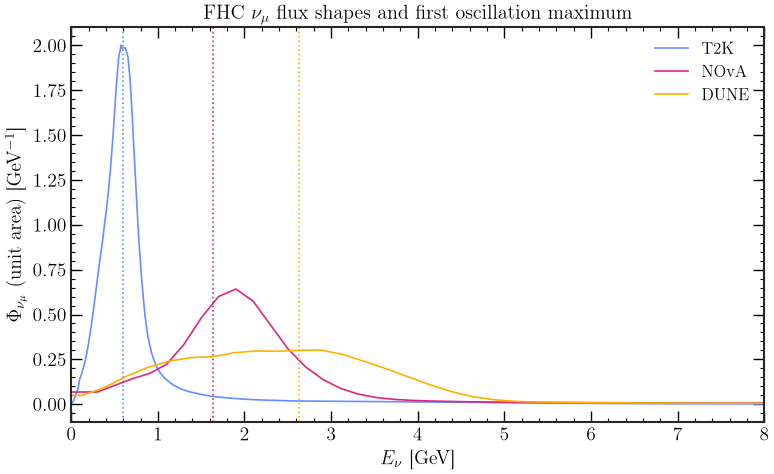

In [ ]:
dm2_31 = NeutrinoOscillator("NO").dm2_31
x = np.linspace(0, 10, 4000)

fig, ax = plt.subplots(figsize=(8, 5))
for i, name in enumerate(COMPARE):
    cfg = get_experiment(name)
    f = load_flux(name, "FHC")
    y = f("numu", x)
    ax.plot(x, y / integrate(x, y), color=c[i], label=name)
    E_max = 2 * K_PHASE * dm2_31 * cfg["baseline"] / np.pi
    ax.axvline(E_max, color=c[i], ls=":", lw=1.2)
ax.set_xlim(0, 8)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\Phi_{\nu_\mu}$ (unit area) [GeV$^{-1}$]")
ax.set_title(r"FHC $\nu_\mu$ flux shapes and first oscillation maximum")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Oscillated fluxes

Multiply the $\nu_\mu$ flux by $P(\nu_\mu\to\nu_\mu)$ and $P(\nu_\mu\to\nu_e)$
(in RHC: the antineutrino probabilities). The appearance flux is multiplied by 10 to be visible;
the probabilities are shown unscaled below. The fast wiggles at low energy are real: they are the
higher oscillation maxima, which a detector with finite resolution cannot resolve (Sec. 6).

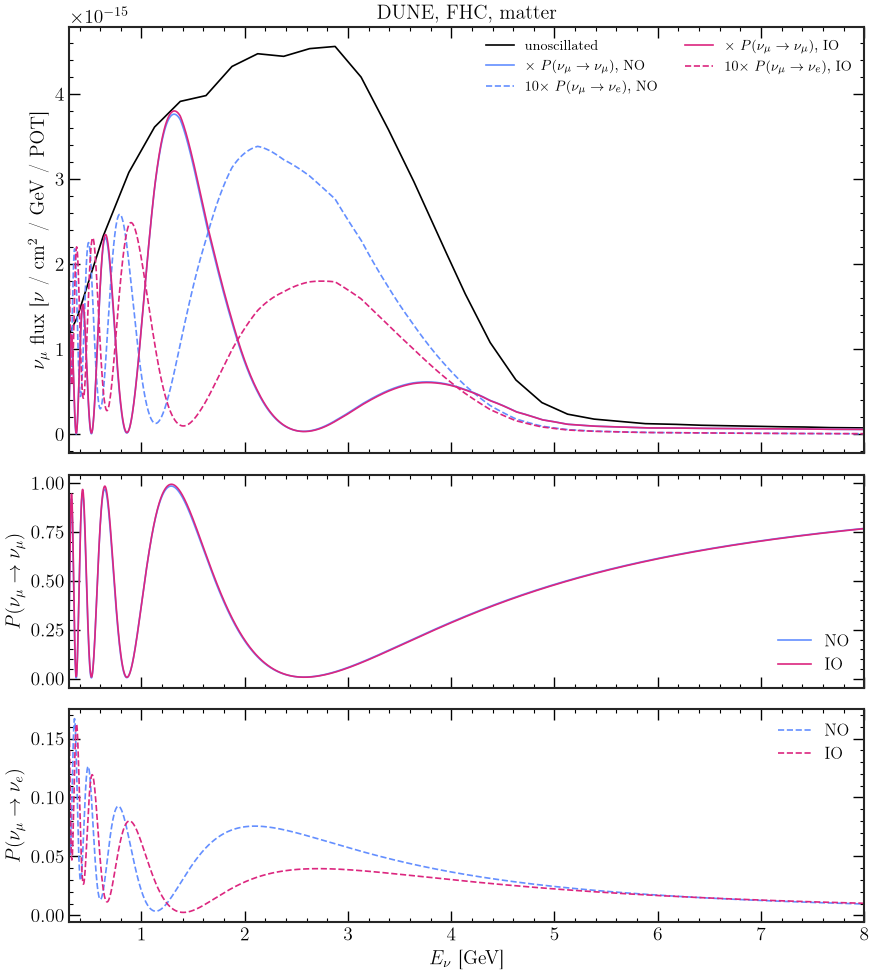

In [ ]:
main = "numu" if MODE == "FHC" else "numubar"
anti = MODE == "RHC"
bar = r"\bar" if anti else ""
Pmm = rf"$P({bar}\nu_\mu\to {bar}\nu_\mu)$"
Pme = rf"$P({bar}\nu_\mu\to {bar}\nu_e)$"
phi = flux[MODE](main, E)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 10), sharex=True,
                                    gridspec_kw=dict(height_ratios=[2, 1, 1]))
ax1.plot(E, phi, color="k", label="unoscillated")
for i, o in enumerate(("NO", "IO")):
    osc[o].antineutrino = anti
    P = osc[o].probability(E=E, matter=MATTER)
    osc[o].antineutrino = False
    ax1.plot(E, phi * P[1, 1], color=c[i], label=r"$\times$ " + Pmm + f", {o}")
    ax1.plot(E, 10 * phi * P[1, 0], color=c[i], ls="--", label=r"$10\times$ " + Pme + f", {o}")
    ax2.plot(E, P[1, 1], color=c[i], label=o)
    ax3.plot(E, P[1, 0], color=c[i], ls="--", label=o)
ax1.set_ylabel(rf"{flav(main)} flux [$\nu$ / cm$^2$ / GeV / POT]")
ax1.set_title(f"{EXPERIMENT}, {MODE}, {'matter' if MATTER else 'vacuum'}")
ax1.legend(ncol=2, fontsize="small")
ax2.set_ylabel(Pmm)
ax3.set_ylabel(Pme)
ax2.legend(); ax3.legend()
ax3.set_xlabel(r"$E_\nu$ [GeV]")
ax3.set_xlim(E[0], E[-1])
plt.tight_layout()
plt.show()

## 3. Event spectra at the far detector (true energy)

* **$\mu$-like** sample ($\nu_\mu$ CC, *disappearance*): right-sign + wrong-sign muon (anti)neutrinos.
* **$e$-like** sample ($\nu_e$ CC, *appearance*): signal $\nu_\mu\to\nu_e$, wrong-sign
  $\bar\nu_\mu\to\bar\nu_e$, and the intrinsic beam $\nu_e + \bar\nu_e$ (grey).

The $e$-like spectrum is shown for four values of $\delta_{CP}$ (NO).

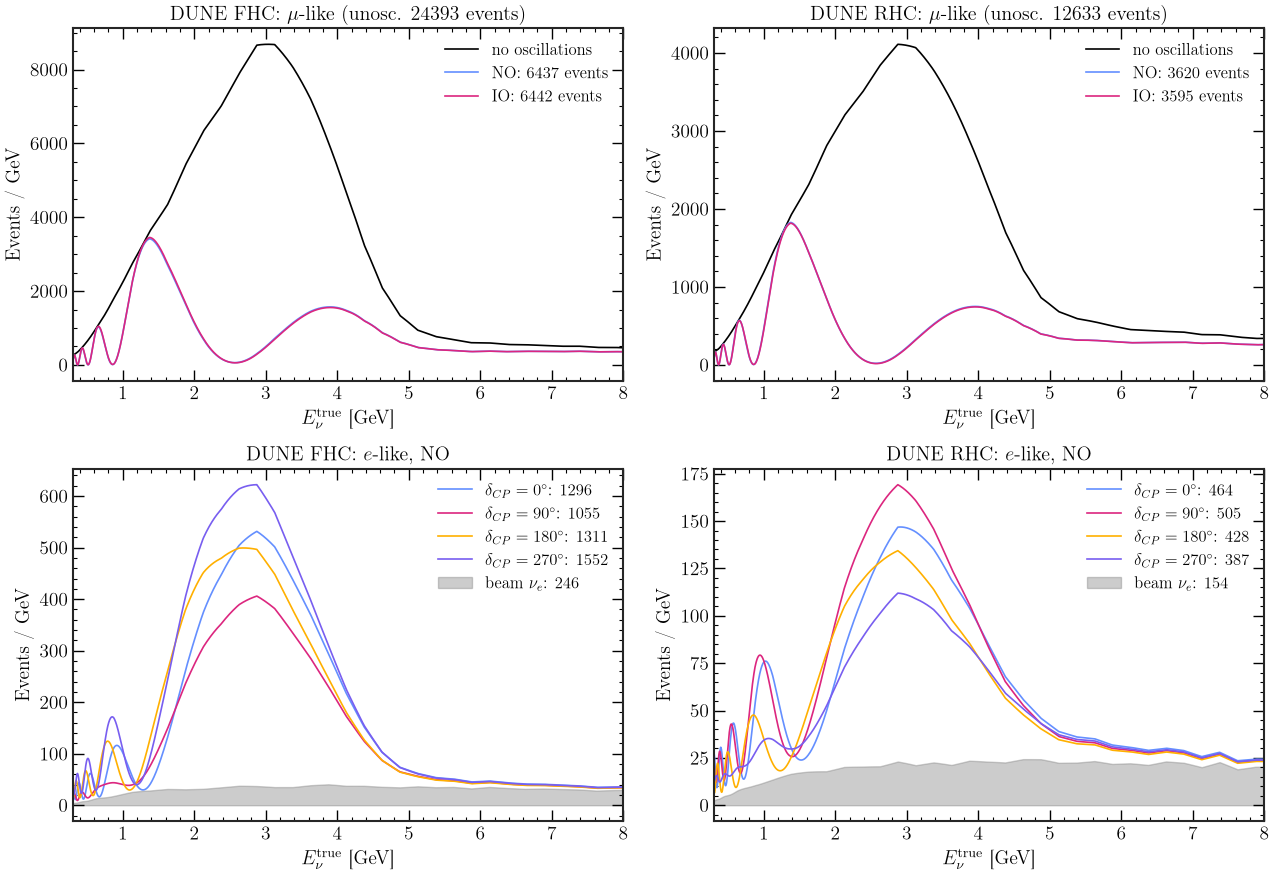

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for col, m in enumerate(("FHC", "RHC")):
    E_, r0 = expected_events(EXPERIMENT, m, osc=None, E=E, flux=flux[m])
    g0 = group_rates(r0, m)
    ax = axes[0, col]
    ax.plot(E, g0["mu_like"], color="k", label="no oscillations")
    for i, o in enumerate(("NO", "IO")):
        _, r = expected_events(EXPERIMENT, m, osc=osc[o], E=E, matter=MATTER, flux=flux[m])
        g = group_rates(r, m)
        ax.plot(E, g["mu_like"], color=c[i], label=f"{o}: {integrate(E, g['mu_like']):.0f} events")
    ax.set_title(rf"{EXPERIMENT} {m}: $\mu$-like (unosc. {integrate(E, g0['mu_like']):.0f} events)")
    ax.set_ylabel("Events / GeV")
    ax.legend()

    ax = axes[1, col]
    o = "NO"
    for i, d in enumerate([0, 90, 180, 270]):
        osc[o].set_params(delta_cp=d)
        _, r = expected_events(EXPERIMENT, m, osc=osc[o], E=E, matter=MATTER, flux=flux[m])
        g = group_rates(r, m)
        ax.plot(E, g["e_like"], color=c[i],
                label=rf"$\delta_{{CP}}={d}^\circ$: {integrate(E, g['e_like']):.0f}")
    osc[o].reset()
    ax.fill_between(E, g["e_beam"], color="grey", alpha=0.4,
                    label=f"beam $\\nu_e$: {integrate(E, g['e_beam']):.0f}")
    ax.set_title(rf"{EXPERIMENT} {m}: $e$-like, NO")
    ax.set_ylabel("Events / GeV")
    ax.legend()
for ax in axes.ravel():
    ax.set_xlabel(r"$E_\nu^\mathrm{true}$ [GeV]")
    ax.set_xlim(E[0], E[-1])
plt.tight_layout()
plt.show()

In [ ]:
# Event table for the selected experiment
print(f"{EXPERIMENT}, E in {exp['E_range']} GeV, {'matter' if MATTER else 'vacuum'}  (true CC events, eff = 1)\n")
header = f"{'':22s}" + "".join(f"{m + ' ' + o:>12s}" for m in ("FHC", "RHC") for o in ("unosc", "NO", "IO"))
print(header)
rows = {}
for m in ("FHC", "RHC"):
    for o in ("unosc", "NO", "IO"):
        _, r = expected_events(EXPERIMENT, m, osc=None if o == "unosc" else osc[o],
                               E=E, matter=MATTER, flux=flux[m])
        for k, v in group_rates(r, m).items():
            rows.setdefault(k, []).append(integrate(E, v))
for k, v in rows.items():
    print(f"{k:22s}" + "".join(f"{x:12.1f}" for x in v))

DUNE, E in (0.3, 8.0) GeV, matter  (true CC events, eff = 1)

                         FHC unosc      FHC NO      FHC IO   RHC unosc      RHC NO      RHC IO
mu_like                    24393.3      6437.1      6442.2     12633.4      3620.2      3595.1
mu_like_rightsign          23439.4      6045.6      6052.9     10350.5      2641.3      2617.0
mu_like_wrongsign            953.9       391.5       389.3      2282.9       978.9       978.1
e_signal                       0.0      1182.7       739.7         0.0       164.6       424.6
e_signal_wrongsign             0.0        12.9        29.9         0.0        81.4        57.2
e_beam                       263.2       245.9       252.7       161.5       153.8       152.5
e_like                       263.2      1441.5      1022.3       161.5       399.8       634.3


## 4. Bi-event plot: $\nu_e$ appearance in FHC vs RHC

The event-level version of the bi-probability plot: total $e$-like events in neutrino mode
vs antineutrino mode, varying $\delta_{CP}$ over $[0, 2\pi)$, for both orderings.
Circles: $\delta_{CP}=0$; squares: $\delta_{CP}=90^\circ$. The size of the ellipses relative to the
statistical error $\sqrt N$ (bars on the $\delta_{CP}=0$ point) tells how well each experiment can
separate the orderings and measure $\delta_{CP}$.

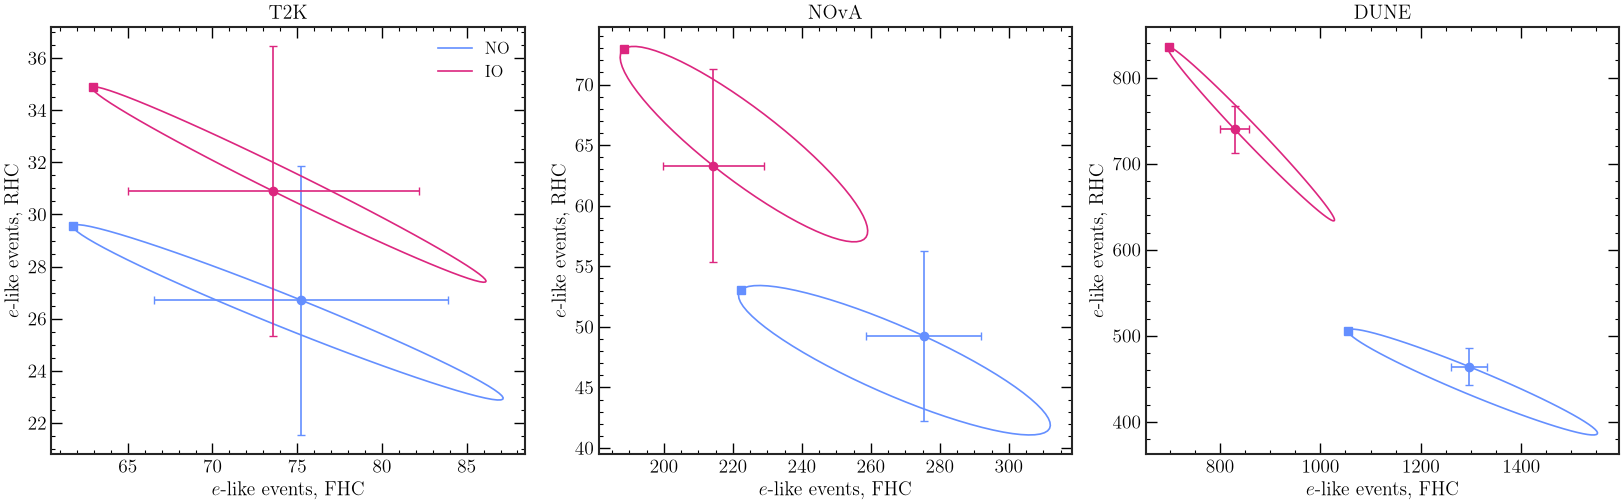

In [ ]:
deltas = np.linspace(0, 360, 73)

fig, axes = plt.subplots(1, len(COMPARE), figsize=(5.5 * len(COMPARE), 5.3), squeeze=False)
for ax, name in zip(axes[0], COMPARE):
    cfg = get_experiment(name)
    Eg = np.linspace(*cfg["E_range"], 1500)
    fl = {m: load_flux(name, m) for m in ("FHC", "RHC")}
    for i, o in enumerate(("NO", "IO")):
        o_ = NeutrinoOscillator(o)
        N = {"FHC": [], "RHC": []}
        for d in deltas:
            o_.set_params(delta_cp=d)
            for m in ("FHC", "RHC"):
                _, r = expected_events(name, m, osc=o_, E=Eg, matter=MATTER, flux=fl[m])
                N[m].append(integrate(Eg, group_rates(r, m)["e_like"]))
        ax.plot(N["FHC"], N["RHC"], color=c[i], label=o)
        ax.errorbar(N["FHC"][0], N["RHC"][0], xerr=np.sqrt(N["FHC"][0]), yerr=np.sqrt(N["RHC"][0]),
                    fmt="o", color=c[i], capsize=3)
        ax.plot(N["FHC"][18], N["RHC"][18], "s", color=c[i])
    ax.set_xlabel(r"$e$-like events, FHC")
    ax.set_ylabel(r"$e$-like events, RHC")
    ax.set_title(f"{name}")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

## 5. Disappearance: the dip, and (again) the weak $\delta_{CP}$ dependence

Ratio of oscillated to unoscillated $\mu$-like events: the dip sits at the first oscillation maximum
and measures $\Delta m^2_{32}$ (position) and $\sin^2 2\theta_{23}$ (depth).
As in the probability notebook, changing $\delta_{CP}$ barely changes the $\mu$-like sample,
while the $e$-like sample changes a lot.

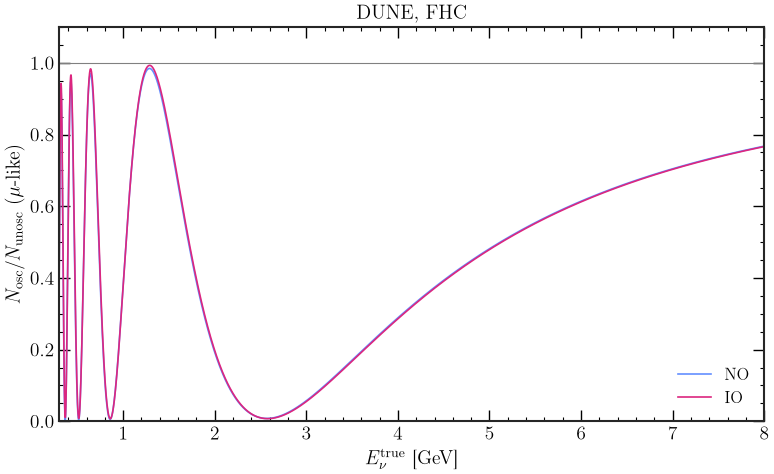

DUNE FHC, NO: total events vs delta_CP
 delta    mu-like     e-like
     0     6458.7     1296.1
    90     6445.3     1055.1
   180     6435.9     1310.9
   270     6445.3     1552.0
relative spread mu_like : 0.4%
relative spread e_like  : 38.1%


In [ ]:
m = MODE
_, r0 = expected_events(EXPERIMENT, m, osc=None, E=E, flux=flux[m])
g0 = group_rates(r0, m)

fig, ax = plt.subplots(figsize=(8, 5))
for i, o in enumerate(("NO", "IO")):
    _, r = expected_events(EXPERIMENT, m, osc=osc[o], E=E, matter=MATTER, flux=flux[m])
    ax.plot(E, group_rates(r, m)["mu_like"] / g0["mu_like"], color=c[i], label=o)
ax.axhline(1, color="grey", lw=0.8)
ax.set_xlim(E[0], E[-1])
ax.set_ylim(0, 1.1)
ax.set_xlabel(r"$E_\nu^\mathrm{true}$ [GeV]")
ax.set_ylabel(r"$N_\mathrm{osc} / N_\mathrm{unosc}$ ($\mu$-like)")
ax.set_title(f"{EXPERIMENT}, {m}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{EXPERIMENT} {m}, NO: total events vs delta_CP")
print(f"{'delta':>6s} {'mu-like':>10s} {'e-like':>10s}")
tot = {"mu_like": [], "e_like": []}
for d in [0, 90, 180, 270]:
    osc["NO"].set_params(delta_cp=d)
    _, r = expected_events(EXPERIMENT, m, osc=osc["NO"], E=E, matter=MATTER, flux=flux[m])
    g = group_rates(r, m)
    for k in tot:
        tot[k].append(integrate(E, g[k]))
    print(f"{d:6d} {tot['mu_like'][-1]:10.1f} {tot['e_like'][-1]:10.1f}")
osc["NO"].reset()
for k in tot:
    v = np.array(tot[k])
    print(f"relative spread {k:8s}: {(v.max() - v.min()) / v.mean():.1%}")

## 6. Reconstructed energy: a toy detector

Real detectors measure a *reconstructed* energy. We smear the true spectrum with a Gaussian of
width $\sigma_E = (\delta E/E)\cdot E$ (value in the configuration) and bin it. The fast
oscillations at low energy are washed out. Note that the true spectrum is computed on a wider
energy range than the plot, so that events can migrate in from outside the window.

As a first taste of a sensitivity study we also compute a simple, **statistics-only**
$\Delta\chi^2$ between the NO and IO predictions (all other parameters fixed, no systematics):
$$\Delta\chi^2 = \sum_i \frac{(N_i^\mathrm{NO} - N_i^\mathrm{IO})^2}{N_i^\mathrm{NO}}.$$
This is *not* a real sensitivity (it ignores degeneracies with $\delta_{CP}$ and $\theta_{23}$), but
it shows which samples carry information.

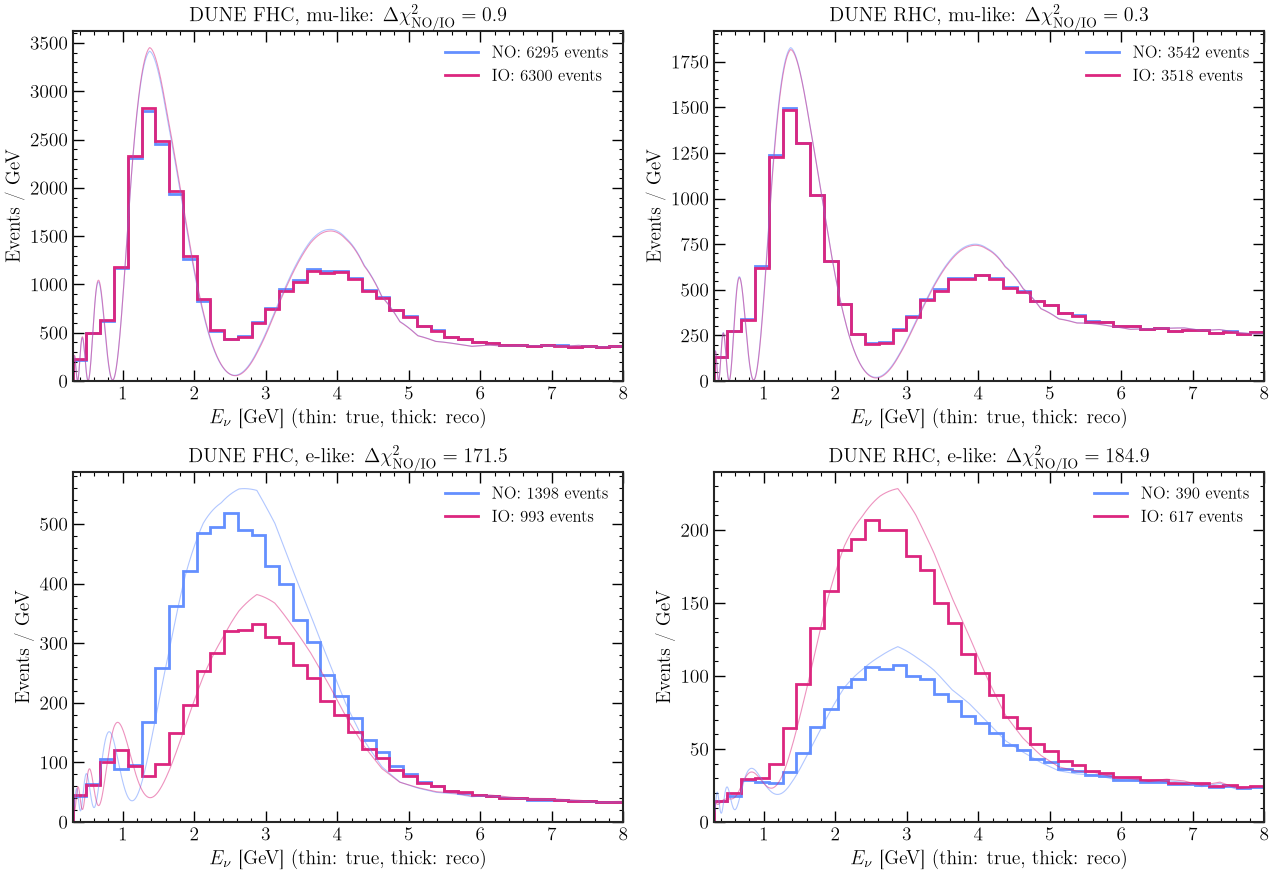

In [ ]:
res = exp["resolution"]
edges = np.linspace(exp["E_range"][0], exp["E_range"][1], 41)
E_reco = np.linspace(0.5 * exp["E_range"][0], 1.2 * exp["E_range"][1], 1500)
# Smear from a WIDER true-energy grid: otherwise events just outside E_range could not
# migrate into the plotted range and the reco spectrum would drop artificially at the edges.
E_wide = np.linspace(0.02, 2 * exp["E_range"][1], 3 * N_ENERGY)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for col, m in enumerate(("FHC", "RHC")):
    for row, sample in enumerate(("mu_like", "e_like")):
        ax = axes[row, col]
        counts = {}
        for i, o in enumerate(("NO", "IO")):
            _, r = expected_events(EXPERIMENT, m, osc=osc[o], E=E_wide, matter=MATTER, flux=flux[m])
            g = group_rates(r, m)[sample]
            reco = smear(E_wide, g, E_reco, res)
            counts[o] = histogram(E_reco, reco, edges)
            ax.plot(E_wide, g, color=c[i], lw=0.8, alpha=0.5)
            ax.stairs(counts[o] / np.diff(edges), edges, color=c[i], lw=2,
                      label=f"{o}: {counts[o].sum():.0f} events")
        m_ = counts["NO"] > 0
        chi2 = np.sum((counts["NO"][m_] - counts["IO"][m_]) ** 2 / counts["NO"][m_])
        ax.set_title(rf"{EXPERIMENT} {m}, {sample.replace('_', '-')}: $\Delta\chi^2_\mathrm{{NO/IO}} = {chi2:.1f}$")
        ax.set_xlabel(r"$E_\nu$ [GeV]  (thin: true, thick: reco)")
        ax.set_ylabel("Events / GeV")
        ax.set_xlim(edges[0], edges[-1])
        ax.legend()
plt.tight_layout()
plt.show()

## 7. Summary: all experiments

True CC events (efficiency 1) in the configured energy range, NuFIT best fit for each ordering.

In [ ]:
print(f"{'':6s} {'mode':5s} {'ord':4s} {'mu-like unosc':>14s} {'mu-like':>9s} {'e-like':>8s} "
      f"{'e signal':>9s} {'e beam':>7s}")
for name in COMPARE:
    cfg = get_experiment(name)
    Eg = np.linspace(*cfg["E_range"], N_ENERGY)
    for m in ("FHC", "RHC"):
        fl = load_flux(name, m)
        _, r0 = expected_events(name, m, osc=None, E=Eg, flux=fl)
        n0 = integrate(Eg, group_rates(r0, m)["mu_like"])
        for o in ("NO", "IO"):
            _, r = expected_events(name, m, osc=NeutrinoOscillator(o), E=Eg, matter=MATTER, flux=fl)
            g = {k: integrate(Eg, v) for k, v in group_rates(r, m).items()}
            print(f"{name:6s} {m:5s} {o:4s} {n0:14.0f} {g['mu_like']:9.0f} {g['e_like']:8.1f} "
                  f"{g['e_signal']:9.1f} {g['e_beam']:7.1f}")

       mode  ord   mu-like unosc   mu-like   e-like  e signal  e beam
T2K    FHC   NO             1510       439     80.5      54.1    25.5
T2K    FHC   IO             1510       438     86.0      59.3    25.6
T2K    RHC   NO              589       194     24.1      10.9    10.4
T2K    RHC   IO              589       193     27.4      13.8    10.4
NOvA   FHC   NO             5286      1389    283.2     212.1    68.2
NOvA   FHC   IO             5286      1382    257.3     183.0    69.2
NOvA   RHC   NO             1188       338     42.5      19.7    16.9
NOvA   RHC   IO             1188       336     57.1      35.1    16.8
DUNE   FHC   NO            24393      6437   1441.5    1182.7   245.9
DUNE   FHC   IO            24393      6442   1022.3     739.7   252.7
DUNE   RHC   NO            12633      3620    399.8     164.6   153.8
DUNE   RHC   IO            12633      3595    634.3     424.6   152.5


## 8. Confronting real data: NOvA 2024 far-detector $\nu_\mu$ sample

NOvA does not publish its far-detector flux, and scaling the near-detector flux by $1/L^2$
(what `load_flux("NOvA")` does) is only approximate. NOvA *does* publish its far-detector data and
its **no-oscillation prediction** (files in `data/NOvA_2024_FD_release/`, see `nuosc/data.py`).
That prediction already contains the true FD flux, cross sections, efficiencies and energy
resolution, so the most realistic thing we can do is simply

$$N_i^\mathrm{pred} = N_i^\mathrm{no\,osc} \times \langle P_{\mu\mu}\rangle_i + \text{beam bkg} + \text{cosmics},$$

with $\langle P_{\mu\mu}\rangle_i$ our probability averaged over the reconstructed-energy bin $i$
(Gaussian resolution of 9%). We compare with NOvA's own best-fit prediction and with the data.

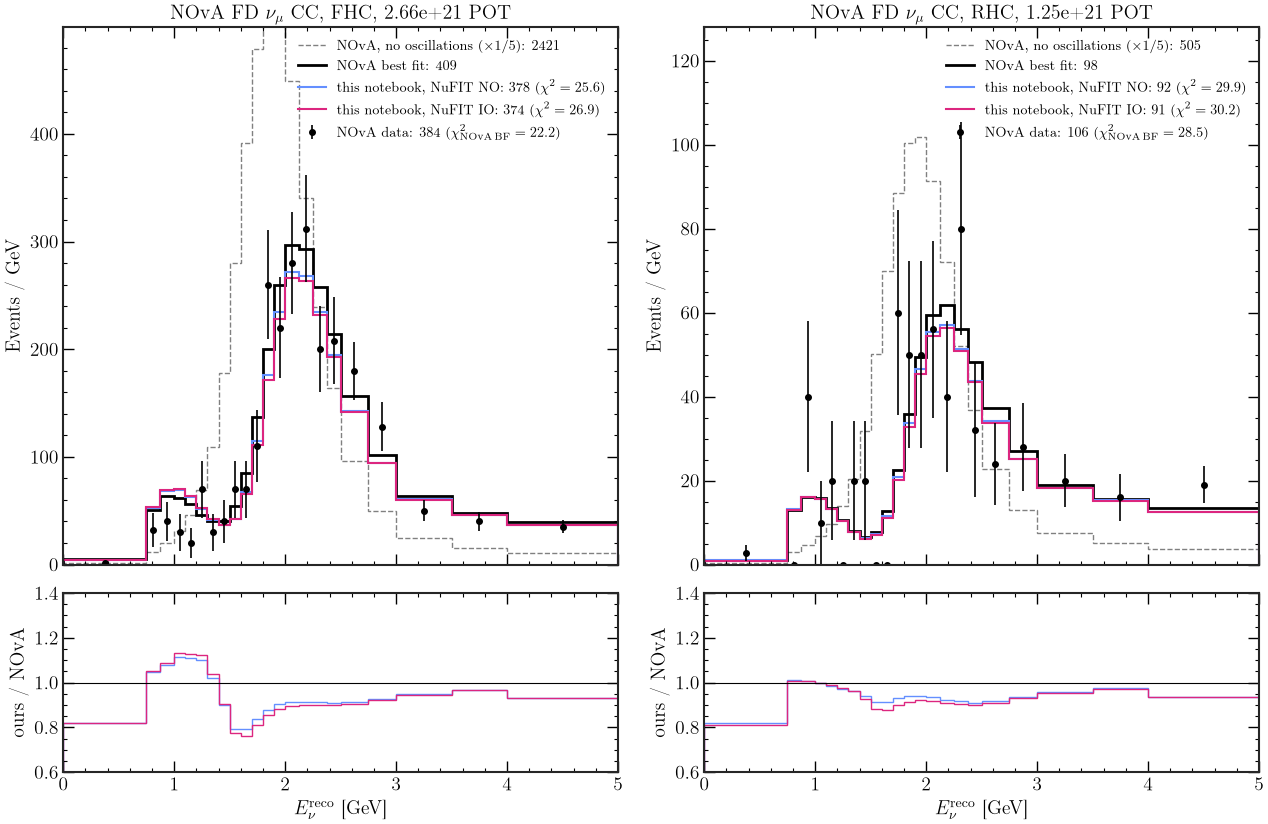

22 bins per sample; the chi^2 uses statistical errors only.


In [ ]:
from nuosc.data import (load_nova_2024_numu, load_nova_2024_nue_totals,
                        reweight_nova_numu, poisson_chi2)

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))
for col, m in enumerate(("FHC", "RHC")):
    s = load_nova_2024_numu(m)
    edges, w = s["edges"], np.diff(s["edges"])
    ctr = 0.5 * (edges[:-1] + edges[1:])
    ax, axr = axes[0, col], axes[1, col]
    ax.stairs(s["noosc_total"] / w / 5, edges, color="grey", ls="--",
              label=f"NOvA, no oscillations ($\\times 1/5$): {s['noosc_total'].sum():.0f}")
    ax.stairs(s["osc_total"] / w, edges, color="k", lw=2,
              label=f"NOvA best fit: {s['osc_total'].sum():.0f}")
    for i, o in enumerate(("NO", "IO")):
        pred = reweight_nova_numu(NeutrinoOscillator(o), m)
        ax.stairs(pred / w, edges, color=c[i], lw=1.5,
                  label=rf"this notebook, NuFIT {o}: {pred.sum():.0f} ($\chi^2 = {poisson_chi2(s['data'], pred):.1f}$)")
        axr.stairs(pred / s["osc_total"], edges, color=c[i])
    ax.errorbar(ctr, s["data"] / w, yerr=np.sqrt(s["data"]) / w, fmt="o", color="k", ms=4,
                label=rf"NOvA data: {s['data'].sum():.0f} ($\chi^2_\mathrm{{NOvA\,BF}} = {poisson_chi2(s['data'], s['osc_total']):.1f}$)")
    ax.set_ylim(0, 1.6 * max((s["osc_total"] / w).max(), (s["data"] / w).max()))
    ax.set_ylabel("Events / GeV")
    ax.set_title(rf"NOvA FD $\nu_\mu$ CC, {m}, {s['pot']:.3g} POT")
    ax.legend(fontsize="small")
    axr.axhline(1, color="k", lw=0.8)
    axr.set_ylim(0.6, 1.4)
    axr.set_ylabel("ours / NOvA")
    axr.set_xlabel(r"$E_\nu^\mathrm{reco}$ [GeV]")
    axr.set_xlim(edges[0], edges[-1])
plt.tight_layout()
plt.show()
print(f"{len(s['data'])} bins per sample; the chi^2 uses statistical errors only.")

### 8a. Why our NOvA flux is only approximate

Dividing NOvA's no-oscillation selected spectrum by our flux-based *true* rate (Sec. 3) gives an
"effective efficiency". It is not flat: it contains the real selection efficiency (low at low
energy and for uncontained high-energy muons) **and** the near-to-far flux difference: the near
detector sees the decay pipe under a range of angles, so its spectrum is broader than the one at
the far detector. This is the origin of the broad tails of the NOvA spectra in the previous sections.

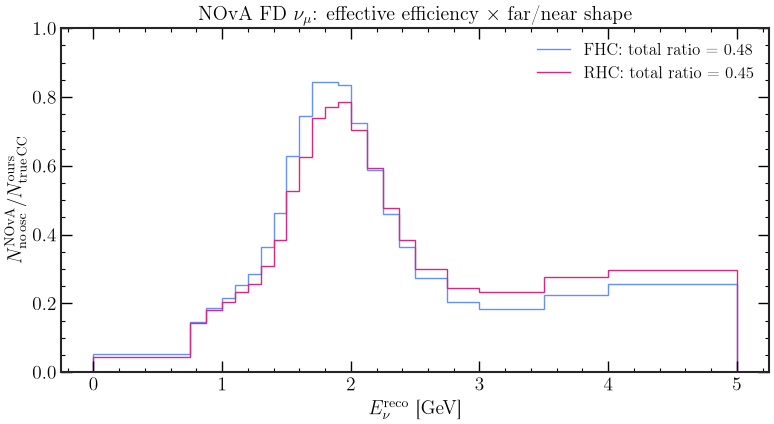

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, m in enumerate(("FHC", "RHC")):
    s = load_nova_2024_numu(m)
    Eg = np.linspace(0.02, 12, 6000)
    _, r = expected_events("NOvA", m, osc=None, E=Eg, pot=s["pot"])
    g = group_rates(r, m)["mu_like"]
    Er = np.linspace(0, 8, 3000)
    ours = histogram(Er, smear(Eg, g, Er, 0.09), s["edges"])
    ax.stairs(s["noosc_signal"] / ours, s["edges"], color=c[i],
              label=f"{m}: total ratio = {s['noosc_signal'].sum() / ours.sum():.2f}")
ax.set_xlabel(r"$E_\nu^\mathrm{reco}$ [GeV]")
ax.set_ylabel(r"$N^\mathrm{NOvA}_\mathrm{no\,osc} / N^\mathrm{ours}_\mathrm{true\,CC}$")
ax.set_title(r"NOvA FD $\nu_\mu$: effective efficiency $\times$ far/near shape")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# nu_e appearance: NOvA totals vs our (efficiency = 1) signal estimate from the ND-scaled flux
nue = load_nova_2024_nue_totals()
print(f"{'sample':14s} {'data':>6s} {'NOvA pred':>10s} {'NOvA signal':>12s} {'beam nue':>9s} {'NC':>6s}")
for k, v in nue.items():
    print(f"{k:14s} {v['data']:6.0f} {v['total_pred']:10.1f} {v['signal']:12.1f} {v['beam_nue_bkg']:9.1f} {v['NC_bkg']:6.1f}")

print("\nThis notebook (true CC, eff = 1, NuFIT NO):")
for m in ("FHC", "RHC"):
    Eg = np.linspace(0.3, 6, N_ENERGY)
    _, r = expected_events("NOvA", m, osc=NeutrinoOscillator("NO"), E=Eg)
    g = group_rates(r, m)
    print(f"  {m}: signal {integrate(Eg, g['e_signal']):6.1f}, beam nue {integrate(Eg, g['e_beam']):5.1f}")

sample           data  NOvA pred  NOvA signal  beam nue     NC
nue_fhc           169      180.7        125.3      26.1   16.8
nue_rhc            32       31.1         18.9       6.5    2.0
nue_lowe_fhc       12       10.5          3.4       0.8    5.3

This notebook (true CC, eff = 1, NuFIT NO):
  FHC: signal  212.1, beam nue  68.2
  RHC: signal   19.7, beam nue  16.9


## 9. Confronting real data: T2K Run 1–9

T2K does not publish its far-detector spectra, but its paper
([arXiv:2101.03779](https://arxiv.org/abs/2101.03779), Table XI) gives the **predicted total number of
events** in each Super-K sample for four values of $\delta_{CP}$, and the **observed** numbers.
The data release (`data/T2K_OA2019_release/`) gives the official $\Delta\chi^2(\delta_{CP})$.

A simple, *rate-only* model: for each $e$-like sample

$$N(\delta_{CP}) = \varepsilon\, S(\delta_{CP}) + B,$$

where $S$ is our $\nu_\mu\to\nu_e$ (+ wrong-sign) CC rate from the T2K flux and the linear cross
section, $\varepsilon$ an effective efficiency and $B$ a $\delta_{CP}$-independent background
(beam $\nu_e$, NC, ...). We fix $\varepsilon$ and $B$ with two of the T2K predictions
($\delta_{CP}=\pm\pi/2$) and then *check* the other two ($\delta_{CP}=0,\pi$).

In [ ]:
from nuosc.data import (T2K_OA2019_POT, t2k_oscillator, load_t2k_oa2019_rates,
                        load_t2k_oa2019_dchi2_dcp)

t2k_pred, t2k_obs = load_t2k_oa2019_rates()
Eg = np.linspace(0.05, 10, 5000)
t2k_flux = {m: load_flux("T2K", m) for m in ("FHC", "RHC")}

def t2k_signal(osc):
    # our e-like signal (right + wrong sign) for FHC and RHC, true CC, eff = 1
    out = {}
    for m in ("FHC", "RHC"):
        _, r = expected_events("T2K", m, osc=osc, E=Eg, pot=T2K_OA2019_POT[m], flux=t2k_flux[m])
        g = group_rates(r, m)
        out[m] = integrate(Eg, g["e_signal"] + g["e_signal_wrongsign"])
    return out

samples = {"FHC_e_like": "FHC", "RHC_e_like": "RHC", "FHC_e_CC1pi": "FHC"}
d1, d2 = -1.5708, 1.5708
S1, S2 = t2k_signal(t2k_oscillator(d1)), t2k_signal(t2k_oscillator(d2))
calib = {}
for smp, m in samples.items():
    eps = (t2k_pred[d1][smp] - t2k_pred[d2][smp]) / (S1[m] - S2[m])
    calib[smp] = (m, eps, t2k_pred[d1][smp] - eps * S1[m])
    print(f"{smp:12s}: eps = {calib[smp][1]:.3f}, B = {calib[smp][2]:.2f} events")

def t2k_model(osc):
    S = t2k_signal(osc)
    return {smp: eps * S[m] + B for smp, (m, eps, B) in calib.items()}

print(f"\n{'delta_CP':>9s} " + " ".join(f"{s:>22s}" for s in samples))
for d in sorted(t2k_pred):
    ours = t2k_model(t2k_oscillator(d))
    print(f"{d:9.3f} " + " ".join(f"{ours[s]:9.1f} (T2K {t2k_pred[d][s]:5.1f})" for s in samples))
print(f"{'observed':>9s} " + " ".join(f"{t2k_obs[s]:22.0f}" for s in samples))

FHC_e_like  : eps = 1.281, B = 11.16 events
RHC_e_like  : eps = 0.699, B = 7.03 events
FHC_e_CC1pi : eps = 0.113, B = 1.42 events

 delta_CP             FHC_e_like             RHC_e_like            FHC_e_CC1pi
   -1.571      74.4 (T2K  74.4)      17.1 (T2K  17.1)       7.0 (T2K   7.0)
    0.000      63.0 (T2K  62.2)      19.7 (T2K  19.6)       6.0 (T2K   6.1)
    1.571      50.6 (T2K  50.6)      21.7 (T2K  21.7)       4.9 (T2K   4.9)
    3.142      62.0 (T2K  62.7)      19.1 (T2K  19.3)       5.9 (T2K   5.9)
 observed                     75                     15                     15


### 9a. Bi-event plot with the T2K data

Our ellipses (NO and IO, varying $\delta_{CP}$), T2K's own predictions (crosses) and the observed
event counts. The data sit at the edge of the NO ellipse near $\delta_{CP}=-\pi/2$: that is the
famous T2K hint for maximal CP violation.

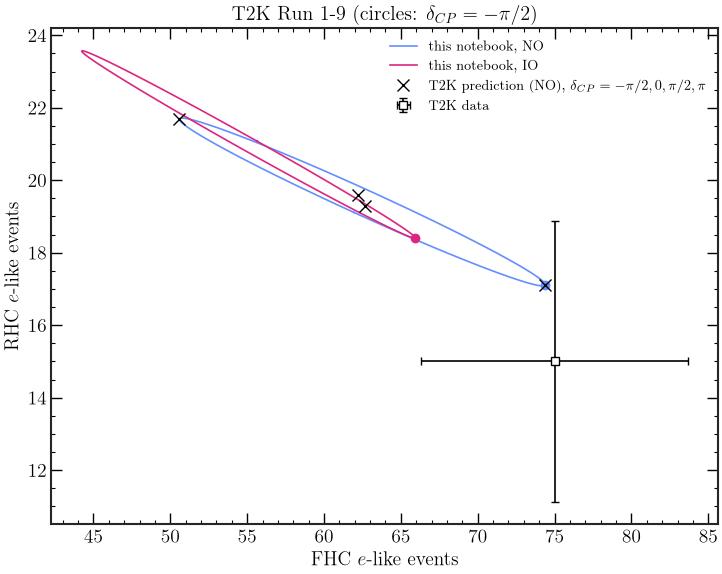

In [ ]:
deltas = np.linspace(-np.pi, np.pi, 73)
fig, ax = plt.subplots(figsize=(7.5, 6))
for i, o in enumerate(("NO", "IO")):
    N = [t2k_model(t2k_oscillator(d, o)) for d in deltas]
    ax.plot([n["FHC_e_like"] for n in N], [n["RHC_e_like"] for n in N], color=c[i], label=f"this notebook, {o}")
    n0 = t2k_model(t2k_oscillator(-np.pi / 2, o))
    ax.plot(n0["FHC_e_like"], n0["RHC_e_like"], "o", color=c[i])
ax.plot([t2k_pred[d]["FHC_e_like"] for d in t2k_pred], [t2k_pred[d]["RHC_e_like"] for d in t2k_pred],
        "kx", ms=9, label=r"T2K prediction (NO), $\delta_{CP}=-\pi/2, 0, \pi/2, \pi$")
ax.errorbar(t2k_obs["FHC_e_like"], t2k_obs["RHC_e_like"], xerr=np.sqrt(t2k_obs["FHC_e_like"]),
            yerr=np.sqrt(t2k_obs["RHC_e_like"]), fmt="s", color="k", mfc="w", capsize=3, label="T2K data")
ax.set_xlabel(r"FHC $e$-like events")
ax.set_ylabel(r"RHC $e$-like events")
ax.set_title("T2K Run 1-9 (circles: $\\delta_{CP}=-\\pi/2$)")
ax.legend(fontsize="small")
plt.tight_layout()
plt.show()

### 9b. A rate-only fit of $\delta_{CP}$

Poisson $\chi^2$ of the three $e$-like counts vs $\delta_{CP}$, for both orderings (all other
parameters fixed to the T2K reference values, no systematics), compared with the official T2K
result, which also uses the energy/angle shapes, the $\mu$-like samples, all systematics and the
reactor constraint on $\theta_{13}$.

Our curves are relative to the global minimum over both orderings. The official curves, as stored
in the release, each start from zero, i.e. the official IO curve is relative to the IO minimum:
compare its *shape* with ours. Almost all of the $\delta_{CP}$ information of T2K is already in
the three $e$-like event counts!

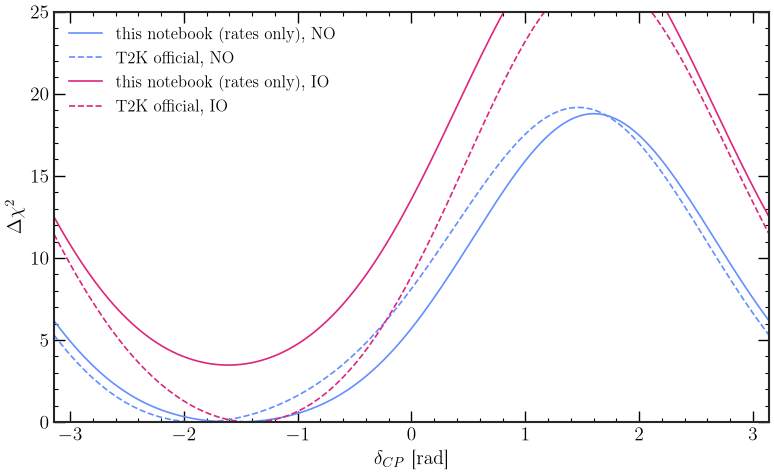

best fit (this notebook): delta_CP = -1.57 rad (NO)


In [ ]:
def poisson_chi2_counts(obs, pred):
    return sum(2 * (pred[k] - obs[k] + obs[k] * np.log(obs[k] / pred[k])) for k in pred)

dgrid = np.linspace(-np.pi, np.pi, 145)
chi = {o: np.array([poisson_chi2_counts(t2k_obs, t2k_model(t2k_oscillator(d, o))) for d in dgrid])
       for o in ("NO", "IO")}
chi_min = min(chi["NO"].min(), chi["IO"].min())

fig, ax = plt.subplots(figsize=(8, 5))
for i, o in enumerate(("NO", "IO")):
    ax.plot(dgrid, chi[o] - chi_min, color=c[i], label=f"this notebook (rates only), {o}")
    x, y = load_t2k_oa2019_dchi2_dcp(o)
    ax.plot(x, y, color=c[i], ls="--", label=f"T2K official, {o}")
ax.set_xlabel(r"$\delta_{CP}$ [rad]")
ax.set_ylabel(r"$\Delta\chi^2$")
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(0, 25)
ax.legend()
plt.tight_layout()
plt.show()
print(f"best fit (this notebook): delta_CP = {dgrid[np.argmin(chi['NO'])]:.2f} rad (NO)")

### Things to try

* Switch `EXPERIMENT` and `MODE`, or turn `MATTER = False`: how much do the $e$-like counts change?
* Change the exposure (`pot`) or mass in `nuosc/experiments.py` and watch the $\sqrt N$ error bars in the bi-event plot shrink.
* Add a detection efficiency: `expected_events(..., efficiency={"numu->nue": 0.6, "numu->numu": 0.8})`.
* Replace the linear cross section with a better one (e.g. a table from GENIE) in `nuosc/rates.py`.